In [46]:
import pandas as pd
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.io import fits

In [47]:
lhs = 0.35*0.35/0.65

In [ ]:
# 2 pi me k / h^2 in cgs
def saha_equation(T, chi_ion, g0=2, g1=1):
    k = 1.380649e-16  # Boltzmann constant in erg/K
    h = 6.62607015e-27  # Planck constant in erg*s
    m_e = 9.10938356e-28  # Electron mass in grams
    eV_to_erg = 1.602176634e-12  # Conversion factor
    
    # Convert chi_ion from eV to ergs
    chi_ion_erg = chi_ion * eV_to_erg
    
    # Calculate the partition function ratio (g1/g0)
    partition_function_ratio = g1 / g0
    
    # Calculate the exponential term
    exponential_term = np.exp(-chi_ion_erg / (k * T))
    
    # Calculate the Saha equation result
    saha_result = (2 * np.pi * m_e * k * T / h**2)**(3/2) * 1 * exponential_term
    return saha_result

# Example usage:
temperature = 10000  # Temperature in Kelvin
chi_ion = 2.18e-11
result = saha_equation(temperature, chi_ion)
print(f"Saha equation result: {result/0.5:.3e}")

Saha equation result: 2.415e+21


In [71]:
k = 1.380649e-16  # Boltzmann constant in erg/K
T = 10000  # Temperature in Kelvin
exponential_term = np.exp(-chi_ion / (k * T))

print(f"Exponential term: {exponential_term:.3e}")

Exponential term: 1.389e-07


0.5384615384615384

In [56]:
print(f"Saha equation result for T={temperature} K and chi_ion={chi_ion} eV: {result:.3e}")

Saha equation result for T=9500 K and chi_ion=13.6 eV: 0.000e+00


In [67]:
r = (8.86 * 10**21 * np.exp(-16.59))/0.5
print(f"Calculated ionization ratio: {r:.3e}")

Calculated ionization ratio: 1.105e+15


In [7]:
summary_file = "data/DECam_Candidate_Summary.csv"
merged_summary_file = "data/merged.csv"

In [10]:
def summarise_csv(csv_file):
    df = pd.read_csv(csv_file)
    unique_objects = df['objid'].unique()
    print(f"Total unique objects: {len(unique_objects)}")

    return df, unique_objects

df, unique_objects = summarise_csv(merged_summary_file)

Total unique objects: 15140


In [35]:
test_object = unique_objects[15]
print(f"Example object ID: {test_object}")

Example object ID: T202503050505559m220626


found 1 fits files
processing files 1/1
Total data points: 24
sanity check:
mjds length: 24
mags length: 24
mag_errs length: 24
filters length: 24
Unique filters: {'z', 'r', 'g'}
[60709.12500513 60709.1259474  60712.12191472 60712.12285525
 60719.13798745 60719.13916179 60721.13485462 60721.13583828
 60723.11944976 60723.12040224 60727.12196848 60727.12295479
 60733.11494103 60733.11588614 60736.09896689 60736.09989087
 60739.09550591 60739.09644235 60739.09760946 60742.04590368
 60742.07073475 60743.07999088 60745.07499131 60745.10105249] [        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan 22.73648071
 21.45830536         nan         nan         nan         nan 21.26028442] [   nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
    nan    nan    nan    nan    nan    nan    nan 0.1097 0.0785    nan
    nan    nan    n

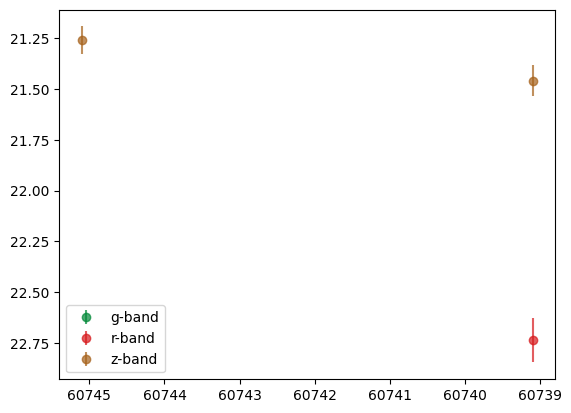

In [45]:
def plot_lightcurve(object):
    data_files = glob.glob(f"data/Candidates/*{object}*")
    print(f"found {len(data_files)} fits files")

    mjds, mags, mag_errs, filters = [], [], [], []
    for i, data in enumerate(data_files):
        print(f"processing files {i+1}/{len(data_files)}")
        with fits.open(data) as hdul:
            # Use extend() to flatten the arrays from each FITS file
            mjds.extend(hdul[1].data['MJD_OBS'])
            mags.extend(hdul[1].data['MAG_ALT'])
            mag_errs.extend(hdul[1].data['MAGERR_ALT'])
            filters.extend(hdul[1].data['FILTER'])

    print(f"Total data points: {len(mjds)}")
    print(f"sanity check:\nmjds length: {len(mjds)}\nmags length: {len(mags)}\nmag_errs length: {len(mag_errs)}\nfilters length: {len(filters)}")
   
    print(f"Unique filters: {set(filters)}")
   
    mjds = np.array(mjds)
    mags = np.array(mags)
    mag_errs = np.array(mag_errs)
    filters = np.array(filters)

    filter_colors = {
    'u': '#7B3294',  # Purple
    'g': '#008837',  # Green
    'r': '#D7191C',  # Red
    'i': '#FDAE61',  # Orange/Gold
    'z': '#A6611A',  # Brown
    'Y': '#000000'   # Black 
        }
    print(mjds, mags, mag_errs, filters)

    # # make data for each filter
    for f in np.unique(filters):
        # check how many data points we have for this filter
        num_points = np.sum(filters == f)
        print(f"Filter {f}: {num_points} data points")
        c = None
        if f in filter_colors:
            c = filter_colors[f]
        else:
            c = 'purple'  # default color for unknown filters
        mask = filters == f

        if not f == "r" or not f == "z":
            plt.errorbar(mjds[mask], mags[mask], yerr=mag_errs[mask], fmt='o', color=c, alpha=0.7, label=f"{f}-band")

    # plt.errorbar(mjds, mags, yerr=mag_errs, fmt='o', color='blue', alpha=0.7, label="All filters")

    # # make data for each filter
    # for f in np.unique(filters):
    #     c = 'green' if f == 'g' else 'red' if f == 'r' else 'black' if f == 'z' else 'black'
    #     mask = filters == f

    #     plt.errorbar(t_jd[mask], mags[mask], yerr=mag_errs[mask], fmt='o', color=c, alpha=0.7)
    #     plt.errorbar(t_jd[mask], mags[mask], fmt='o', color=c)

    # plt.xlabel("MJD")
    # plt.ylabel("Magnitude")
    # plt.title(f"Light Curve for {object}")
    plt.gca().invert_yaxis()
    plt.gca().invert_xaxis()
    plt.legend()
    # plt.show()

plot_lightcurve(test_object)

In [2]:
summary_file = "data/DECam_Candidate_Summary.csv"
data_dir = "data/Candidates/"

In [44]:
summary_data = pd.read_csv(summary_file)
print("Summary shape:", summary_data.shape)

Summary shape: (6253, 29)


In [45]:
print("Columns in summary data:", summary_data.columns.tolist())

Columns in summary data: ['objid', 'skycoord_obj', 'ra_obj', 'dec_obj', 'ra_obj_maxSNR', 'dec_obj_maxSNR', 'num_alert', 'date_first_alert', 'mag_first_alert', 'magerr_first_alert', 'filter_first_alert', 'date_peak_alert', 'mag_peak_alert', 'magerr_peak_alert', 'filter_peak_alert', 'date_last_alert', 'mag_last_alert', 'magerr_last_alert', 'filter_last_alert', 'lsdr9_id.pseudo_host', 'lsdr9_ra.pseudo_host', 'lsdr9_dec.pseudo_host', 'lsdr9_gmag.pseudo_host', 'lsdr9_rmag.pseudo_host', 'lsdr9_zmag.pseudo_host', 'z.pseudo_host', 'e_z.pseudo_host', 'z_type.pseudo_host', 'z_source.pseudo_host']


In [52]:
unique_objects = summary_data['objid'].unique()
print(f"Number of unique objects: {len(unique_objects)}")

Number of unique objects: 6253


In [55]:
sample_data = summary_data[summary_data['objid'] == unique_objects[0]]
print(f"Sample data for objid {unique_objects[5]}:")
display(sample_data)

Sample data for objid C202502151430225m001022:


,objid,skycoord_obj,ra_obj,dec_obj,ra_obj_maxSNR,dec_obj_maxSNR,num_alert,date_first_alert,mag_first_alert,magerr_first_alert,...,lsdr9_id.pseudo_host,lsdr9_ra.pseudo_host,lsdr9_dec.pseudo_host,lsdr9_gmag.pseudo_host,lsdr9_rmag.pseudo_host,lsdr9_zmag.pseudo_host,z.pseudo_host,e_z.pseudo_host,z_type.pseudo_host,z_source.pseudo_host
0,T202504071346367m032044,13:46:36.703 -03:20:44.327,206.652933,-3.345646,206.652933,-3.345646,3.0,2025-04-07T06:05:04.407,20.729444,0.026255,...,2066m032_3329,206.652706,-3.345873,17.215012,16.482157,15.9519,NaN,NaN,NONE,NONE


In [58]:
sample_data = {
    "obj": unique_objects[0],
    "t1": Time(sample_data['date_first_alert'].values[0], format='isot', scale='utc').mjd,
    "t2": Time(sample_data['date_last_alert'].values[0], format='isot', scale='utc').mjd,
    "t3": Time(sample_data['date_peak_alert'].values[0], format='isot', scale='utc').mjd,


    "f1": sample_data['filter_first_alert'].values[0],
    "f2": sample_data['filter_last_alert'].values[0],
    "f3": sample_data['filter_peak_alert'].values[0],
    
    
    "mag1": sample_data['mag_first_alert'].values[0],
    "mag_err1": sample_data['magerr_first_alert'].values[0],
    "mag2": sample_data['mag_last_alert'].values[0],
    "mag_err2": sample_data['magerr_last_alert'].values[0],
    "mag3": sample_data['mag_peak_alert'].values[0],
    "mag_err3": sample_data['magerr_peak_alert'].values[0],

}

Text(0, 0.5, 'Magnitude')

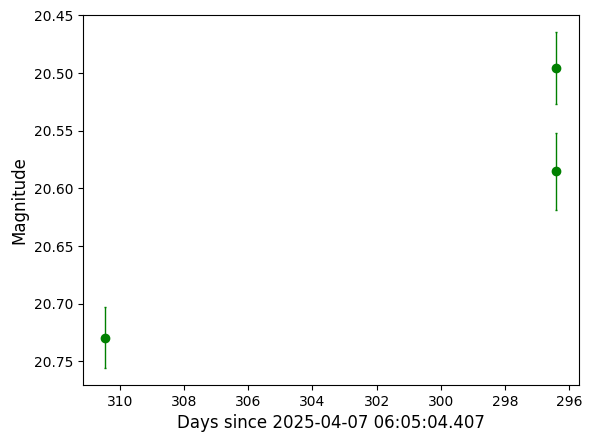

In [69]:
times = [sample_data['t1'], sample_data['t2'], sample_data['t3']]
t_now = Time.now().jd
times_jd = [Time(t, format='mjd').jd for t in times]

t0 = min(times_jd)
t0_iso = Time(t0, format='jd').iso

relative_times = np.abs([t - t_now for t in times_jd])
magnitudes = [sample_data['mag1'], sample_data['mag2'], sample_data['mag3']]
filters = [sample_data['f1'], sample_data['f2'], sample_data['f3']] 
err = [sample_data['mag_err1'], sample_data['mag_err2'], sample_data['mag_err3']]

if filters[0] == filters[1] == filters[2]:
    color = 'green' if filters[0] == 'g' else 'red' if filters[0] == 'r' else 'green'
else:
    color = 'k'  # Default color for mixed filters
plt.errorbar(relative_times, magnitudes, yerr=err, fmt='o', color=color, elinewidth=1, capsize=1)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis() 
plt.xlabel(f'Days since {t0_iso}', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)

## lol

In [73]:
actual_data = glob.glob(f"data/Candidates/*{unique_objects[5]}*fits")
print(f"Actual data files for objid {unique_objects[5]}:", actual_data)

Actual data files for objid C202502151430225m001022: ['data/Candidates/4_C202502151430225m001022.fits']


In [76]:
fi = fits.open(actual_data[0])
print(fi.info())

Filename: data/Candidates/4_C202502151430225m001022.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    105   20R x 37C   [K, 27A, 26A, D, 1A, 3A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 14641E, 14641E, 14641E, D, D, D, D, D, D, D, D, D, D, D, D, D, 1A]   
None


In [77]:
fi[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  

In [78]:
fi[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               175982 / length of dimension 1                          
NAXIS2  =                   20 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   37 / number of table fields                         
TTYPE1  = 'INDEX   '                                                            
TFORM1  = 'K       '                                                            
TTYPE2  = 'SCIENCE_NAME'                                                        
TFORM2  = '27A     '                                                            
TTYPE3  = 'TEMPLATE_NAME'   

In [83]:
print(fi[1].data.columns)

ColDefs(
    name = 'INDEX'; format = 'K'
    name = 'SCIENCE_NAME'; format = '27A'
    name = 'TEMPLATE_NAME'; format = '26A'
    name = 'MJD_OBS'; format = 'D'
    name = 'FILTER'; format = '1A'
    name = 'DETPOS'; format = '3A'
    name = 'X_OBJ'; format = 'D'
    name = 'Y_OBJ'; format = 'D'
    name = 'X_FPHOT'; format = 'D'
    name = 'Y_FPHOT'; format = 'D'
    name = 'X_nSTAR'; format = 'D'
    name = 'Y_nSTAR'; format = 'D'
    name = 'X_nGAL'; format = 'D'
    name = 'Y_nGAL'; format = 'D'
    name = 'X_ALT'; format = 'D'
    name = 'Y_ALT'; format = 'D'
    name = 'MAG_ALT'; format = 'D'
    name = 'MAGERR_ALT'; format = 'D'
    name = 'SNR_ALT'; format = 'D'
    name = 'CNNSCORE_ALT'; format = 'D'
    name = 'PixA_THUMB_TEMP'; format = '14641E'; dim = '(121,121)'
    name = 'PixA_THUMB_SCI'; format = '14641E'; dim = '(121,121)'
    name = 'PixA_THUMB_DIFF'; format = '14641E'; dim = '(121,121)'
    name = 'ZMIN_TEMP'; format = 'D'
    name = 'ZMAX_TEMP'; format = 'D'
    na

In [84]:
fits_data = fi[1].data

In [86]:
data = {
    "mjd": fits_data['MJD_OBS'],
    "mag": fits_data['MAG_ALT'],
    "mag_err": fits_data['MAGERR_ALT'],
    "filter": fits_data['FILTER']
}

Text(0, 0.5, 'Magnitude')

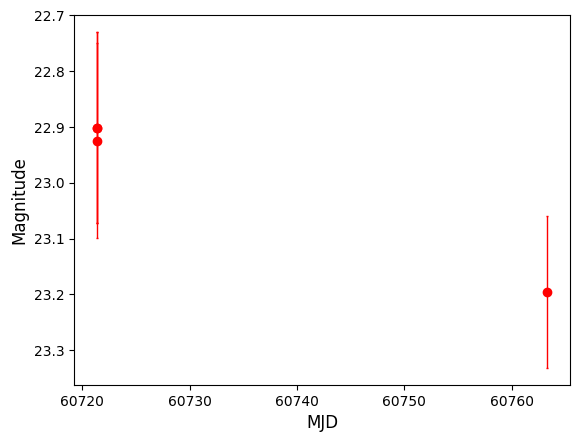

In [ ]:
g_band = data['filter'] == 'g'
r_band = data['filter'] == 'r'

plt.errorbar(data['mjd'][g_band], data['mag'][g_band], yerr=data['mag_err'][g_band], fmt='o', color='green', elinewidth=1, capsize=1, label='g-band')
plt.errorbar(data['mjd'][r_band], data['mag'][r_band], yerr=data['mag_err'][r_band], fmt='o', color='red', elinewidth=1, capsize=1, label='r-band')
plt.gca().invert_yaxis()
plt.xlabel('MJD', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)

Text(0, 0.5, 'Magnitude')

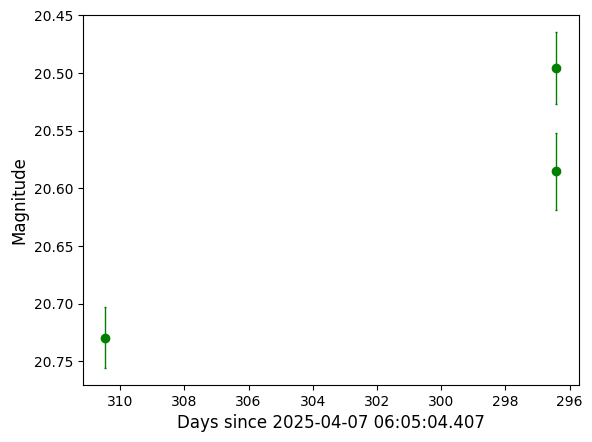

In [92]:
times = [sample_data['t1'], sample_data['t2'], sample_data['t3']]
t_now = Time.now().jd
times_jd = [Time(t, format='mjd').jd for t in times]

t0 = min(times_jd)
t0_iso = Time(t0, format='jd').iso

relative_times = np.abs([t - t_now for t in times_jd])
magnitudes = [sample_data['mag1'], sample_data['mag2'], sample_data['mag3']]
filters = [sample_data['f1'], sample_data['f2'], sample_data['f3']] 
err = [sample_data['mag_err1'], sample_data['mag_err2'], sample_data['mag_err3']]

if filters[0] == filters[1] == filters[2]:
    color = 'green' if filters[0] == 'g' else 'red' if filters[0] == 'r' else 'green'
else:
    color = 'k'  # Default color for mixed filters
plt.errorbar(relative_times, magnitudes, yerr=err, fmt='o', color=color, elinewidth=1, capsize=1)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis() 
plt.xlabel(f'Days since {t0_iso}', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)

In [ ]:
g_times_jd = [Time(t, format='mjd').jd for t in data['mjd'][g_band]]
r_times_jd = [Time(t, format='mjd').jd for t in data['mjd'][r_band]]
t0_fits = min(g_times_jd + r_times_jd)
t0_fits_iso = Time(t0_fits, format='jd').iso

relative_times_g = np.abs([Time(t, format='mjd').jd - t_now for t in data['mjd'][g_band]])
relative_times_r = np.abs([Time(t, format='mjd').jd - t_now for t in data['mjd'][r_band]])

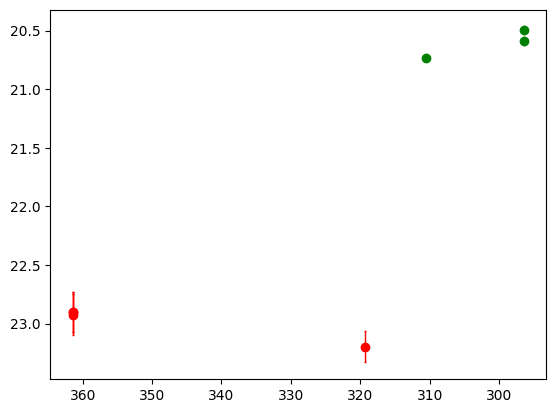

In [96]:
plt.errorbar(relative_times_fits[g_band], data['mag'][g_band], yerr=data['mag_err'][g_band], fmt='o', color='green', elinewidth=1, capsize=1, label='g-band')
plt.errorbar(relative_times_fits[r_band], data['mag'][r_band], yerr=data['mag_err'][r_band], fmt='o', color='red', elinewidth=1, capsize=1, label='r-band')

if filters[0] == filters[1] == filters[2]:
    color = 'green' if filters[0] == 'g' else 'red' if filters[0] == 'r' else 'green'
else:
    color = 'k'  # Default color for mixed filters
plt.errorbar(relative_times, magnitudes, yerr=err, fmt='o', color=color, elinewidth=1, capsize=1)

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

In [ ]:
columns_in_fits = {
    "INDEX",
    "SCIENCE_NAME",
    "TEMPLATE_NAME",
    "MJD_OBS",
    "FILTER",
    "DETPOS",
    "X_OBJ",
    "Y_OBJ",
    "X_FPHOT",
    "Y_FPHOT",
    "X_nSTAR",
    "Y_nSTAR",
    "X_nGAL",
    "Y_nGAL",
    "X_ALT",
    "Y_ALT",
    "MAG_ALT",
    "MAGERR_ALT",
    "SNR_ALT",
    "CNNSCORE_ALT",
    "PixA_THUMB_TEMP",
    "PixA_THUMB_SCI",
    "PixA_THUMB_DIFF",
    "ZMIN_TEMP",
    "ZMAX_TEMP",
    "ZMIN_SCI",
    "ZMAX_SCI",
    "ZMIN_DIFF",
    "ZMAX_DIFF",
    "APER_FPHOT",
    "ZP_FPHOT",
    "LIM_MAG3",
    "LIM_MAG5",
    "MAG_FPHOT",
    "MAGERR_FPHOT",
    "SNR_FPHOT",
    "STATUS_FPHOT"
}

In [7]:
import matplotlib.pyplot as plt
import os
from astropy.io import fits


with fits.open("data/Candidates/0_C202502031408331m013737.fits") as hdul:
    data = hdul[1].data

In [8]:
data["PixA_THUMB_TEMP"]

array([[[  2.9902344 ,   3.9505005 ,   2.1553345 , ...,  -3.6445007 ,
           3.6145325 ,   0.14535522],
        [ 10.703674  ,  14.049805  ,  -3.1343994 , ...,  -7.040497  ,
          -0.8100281 , -22.857178  ],
        [ 16.161285  ,  -4.7243958 ,  -8.561554  , ...,  -6.4545593 ,
          -1.4182129 ,  -8.83725   ],
        ...,
        [  2.605713  ,   9.8984375 ,   0.57229614, ...,  -8.000946  ,
           2.4528198 ,  -3.8366394 ],
        [ -4.9727173 ,   1.8085632 ,  -0.6687622 , ...,  13.252563  ,
          -2.305725  ,   0.04751587],
        [  5.7893066 ,  16.382355  ,   8.826416  , ...,  -8.837616  ,
          -6.2149353 ,  11.16272   ]],

       [[  2.9902344 ,   3.9505005 ,   2.1553345 , ...,  -3.6445007 ,
           3.6145325 ,   0.14535522],
        [ 10.703674  ,  14.049805  ,  -3.1343994 , ...,  -7.040497  ,
          -0.8100281 , -22.857178  ],
        [ 16.161285  ,  -4.7243958 ,  -8.561554  , ...,  -6.4545593 ,
          -1.4182129 ,  -8.83725   ],
        ...,


Text(0.5, 1.0, 'PixA_THUMB_SCI with ZMIN and ZMAX Scaling')

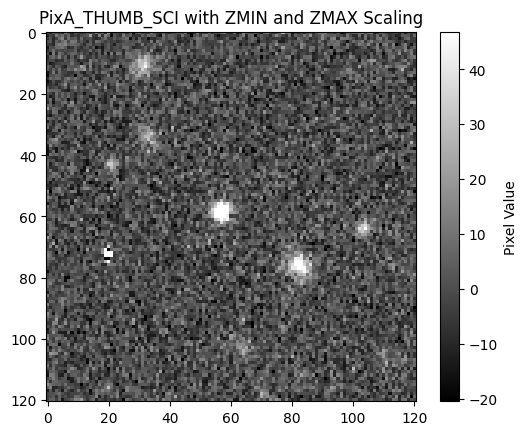

In [12]:
import numpy as np
plt.imshow(data['PixA_THUMB_SCI'][0], cmap='gray')
zmin = np.min(data['ZMIN_SCI'][0])
zmax = np.max(data['ZMAX_SCI'][0])
plt.clim(zmin, zmax)
plt.colorbar(label='Pixel Value')
plt.title('PixA_THUMB_SCI with ZMIN and ZMAX Scaling')